In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np

In [6]:
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()
X_train.shape

d:\AIML Internship\.venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


(50000, 32, 32, 3)

In [7]:
X_test.shape

(10000, 32, 32, 3)

In [8]:
y_train.shape

(50000, 1)

In [9]:
y_test.shape

(10000, 1)

In [10]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [12]:
y_train = y_train.reshape(-1,)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [13]:
y_test = y_test.reshape(-1,)
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

In [14]:
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

In [15]:
def plot_sample_img(X, y, index):
    plt.figure(figsize=(15,2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])

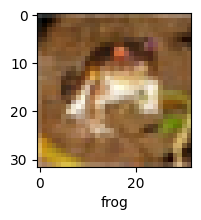

In [16]:
plot_sample_img(X_train, y_train, 0)

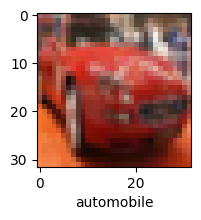

In [17]:
plot_sample_img(X_train, y_train, 5)

In [18]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [20]:
ann = models.Sequential([
    layers.Flatten(input_shape = (32, 32, 3)),
    layers.Dense(3000, activation = "relu"),
    layers.Dense(1000, activation = "relu"),
    layers.Dense(10, activation = "softmax")
])

ann.compile(optimizer = "SGD", loss = "sparse_categorical_crossentropy", metrics = ["accuracy"])
ann.fit(X_train, y_train, epochs = 5)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - accuracy: 0.3542 - loss: 1.8165
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 28ms/step - accuracy: 0.4267 - loss: 1.6274
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - accuracy: 0.4565 - loss: 1.5449
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 28ms/step - accuracy: 0.4788 - loss: 1.4824
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 30ms/step - accuracy: 0.4970 - loss: 1.4353


* Simple NN

In [24]:
from sklearn.metrics import confusion_matrix , classification_report
import numpy as np
y_pred = ann.predict(X_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

print("Classification Report: \n", classification_report(y_test, y_pred_classes))


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Classification Report: 
               precision    recall  f1-score   support

           0       0.50      0.58      0.54      1000
           1       0.62      0.62      0.62      1000
           2       0.39      0.30      0.34      1000
           3       0.42      0.11      0.17      1000
           4       0.45      0.33      0.38      1000
           5       0.34      0.49      0.40      1000
           6       0.38      0.79      0.51      1000
           7       0.70      0.38      0.49      1000
           8       0.52      0.71      0.60      1000
           9       0.63      0.42      0.51      1000

    accuracy                           0.47     10000
   macro avg       0.49      0.47      0.45     10000
weighted avg       0.49      0.47      0.45     10000



* CNN CNN CNN CNN CNN CNN CNN CNN CNN CNN CNN CNN CNN CNN

In [25]:
cnn = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

d:\AIML Internship\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
cnn.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [27]:
cnn.fit(X_train, y_train, epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.4650 - loss: 1.4829
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.6077 - loss: 1.1141
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.6601 - loss: 0.9780
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.6879 - loss: 0.8995
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.7099 - loss: 0.8341
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.7302 - loss: 0.7786
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.7451 - loss: 0.7291
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.7578 - loss: 0.6887
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.7753 - loss: 0.6453
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.7871 - loss: 0.6073


In [28]:
cnn.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6941 - loss: 0.9312


[0.9311938285827637, 0.694100022315979]

In [29]:
y_pred = cnn.predict(X_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


array([[8.4363259e-03, 1.8185583e-05, 3.1766243e-02, 6.2820286e-01,
        3.1067173e-03, 6.7244723e-02, 2.1434152e-01, 8.3338952e-04,
        4.1058216e-02, 4.9918178e-03],
       [1.6776687e-02, 2.3162363e-02, 5.8520486e-06, 3.9433580e-06,
        2.8472373e-06, 6.4296978e-07, 4.3958985e-07, 3.9522902e-07,
        9.5333779e-01, 6.7091230e-03],
       [4.5106575e-02, 8.4668100e-02, 2.0869097e-03, 3.8223341e-03,
        1.3268215e-03, 4.7058417e-04, 1.2642991e-03, 3.5644061e-04,
        7.9848737e-01, 6.2410537e-02],
       [8.4599942e-01, 6.3636755e-03, 8.8099986e-03, 8.4825413e-04,
        1.4360702e-03, 9.2149407e-05, 1.4105098e-05, 8.4272193e-05,
        1.3617724e-01, 1.7480348e-04],
       [2.5054110e-08, 2.6407513e-06, 2.5465959e-03, 2.1298879e-03,
        4.5754652e-02, 4.1687188e-05, 9.4947720e-01, 3.9283424e-07,
        4.6852823e-05, 1.5535764e-07]], dtype=float32)

In [30]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]

[np.int64(3), np.int64(8), np.int64(8), np.int64(0), np.int64(6)]

In [31]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

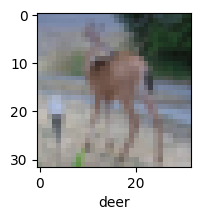

In [35]:
plot_sample_img(X_test, y_test,100)

In [36]:
classes[y_classes[100]]

'deer'